# EDA: Before vs. After — Feature Selection


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df_before = pd.read_csv("output_after_missing_data.csv")
df_after = pd.read_csv("output_after_feature_selection.csv")

print("Before shape:", df_before.shape)
print("After shape:", df_after.shape)

Before shape: (100000, 26)
After shape: (100000, 6)


## EDA 1 — Column Count: Before vs. After

In [9]:
col_counts = pd.Series({"Before (all columns)": df_before.shape[1],
                          "After (selected only)": df_after.shape[1]})
col_counts

Before (all columns)     26
After (selected only)     6
dtype: int64

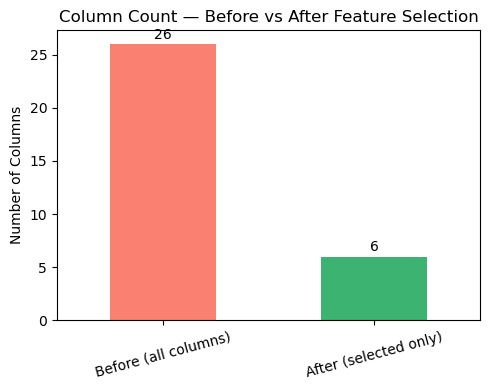

In [10]:
plt.figure(figsize=(5, 4))
col_counts.plot(kind="bar", color=["salmon", "mediumseagreen"])
plt.ylabel("Number of Columns")
plt.title("Column Count — Before vs After Feature Selection")
plt.xticks(rotation=15)
for i, v in enumerate(col_counts):
    plt.text(i, v + 0.5, str(v), ha="center")
plt.tight_layout()
plt.show()

**Interpretation:** Went from 26 columns down to just 6 (5 features + the target). The
dataset was reduced by about 77% in width, while every row (100,000) was kept -
this was a
column-level cut, not a data-loss cut.

## EDA 2 — Proof of Leakage: `satisfaction_level` vs `recommendation_level` (Before)

In [11]:
leak_check = pd.crosstab(df_before["satisfaction_level"], df_before["recommendation_level"])
leak_check

recommendation_level,Highly Recommend,Neutral,Recommend
satisfaction_level,,,
Neutral,0,241,0
Satisfied,0,0,50518
Very Satisfied,49241,0,0


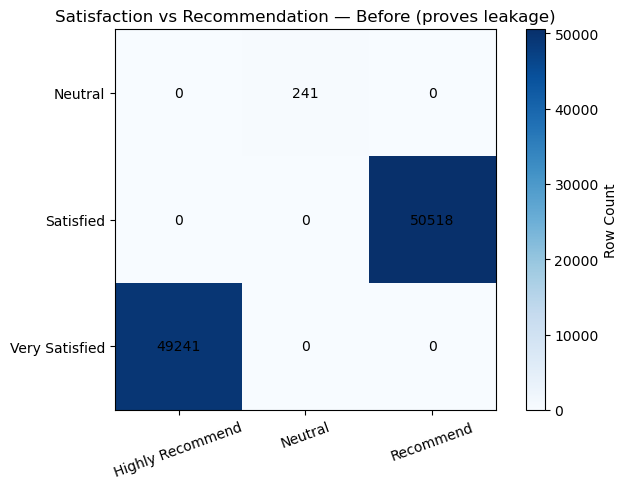

In [12]:
plt.figure(figsize=(7, 5))
plt.imshow(leak_check, cmap="Blues")
plt.colorbar(label="Row Count")
plt.xticks(range(len(leak_check.columns)), leak_check.columns, rotation=20)
plt.yticks(range(len(leak_check.index)), leak_check.index)
plt.title("Satisfaction vs Recommendation — Before (proves leakage)")
for i in range(len(leak_check.index)):
    for j in range(len(leak_check.columns)):
        plt.text(j, i, leak_check.iloc[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

**Interpretation:** Every value sits in a perfect diagonal — no mixing at all. This is why
`recommendation_level` was removed: it's just a renamed copy of the answer, not a real feature.
This column no longer exists in the "after" dataset.

## EDA 3 — Chi-Square Scores: Which Columns Justified Being Kept vs Dropped

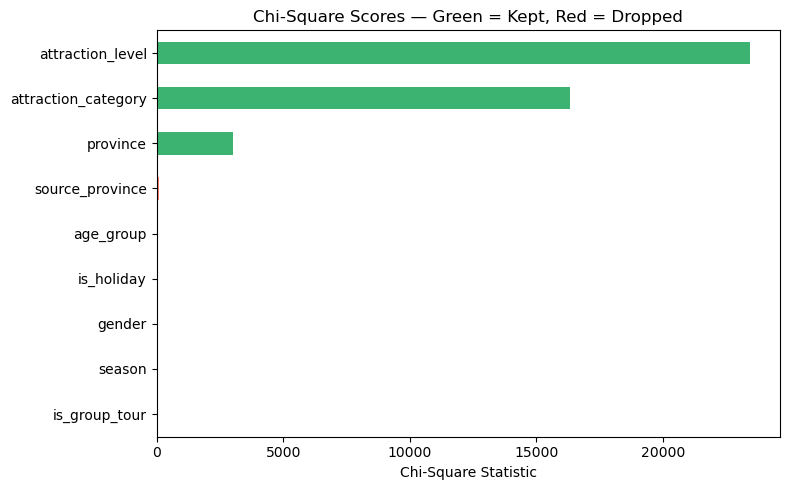

In [13]:
sat_order = ["Neutral", "Satisfied", "Very Satisfied"]

def chi_square_stat(col):
    contingency = pd.crosstab(df_before[col], df_before["satisfaction_level"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    return chi2

candidate_cats = ["gender", "age_group", "season", "is_holiday", "is_group_tour",
                   "attraction_level", "attraction_category", "province", "source_province"]

chi2_scores = pd.Series({c: chi_square_stat(c) for c in candidate_cats}).sort_values(ascending=False)
kept = ["attraction_level", "attraction_category", "province"]
colors = ["mediumseagreen" if c in kept else "salmon" for c in chi2_scores.index]

plt.figure(figsize=(8, 5))
chi2_scores.plot(kind="barh", color=colors)
plt.xlabel("Chi-Square Statistic")
plt.title("Chi-Square Scores — Green = Kept, Red = Dropped")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:** The three columns that survived (green) have dramatically higher
chi-square scores than everything dropped (red) — this is the actual statistical evidence behind
the "before → after" column cut, not a guess.

## EDA 4 — Target Class Balance: Before vs. After (should be unchanged)

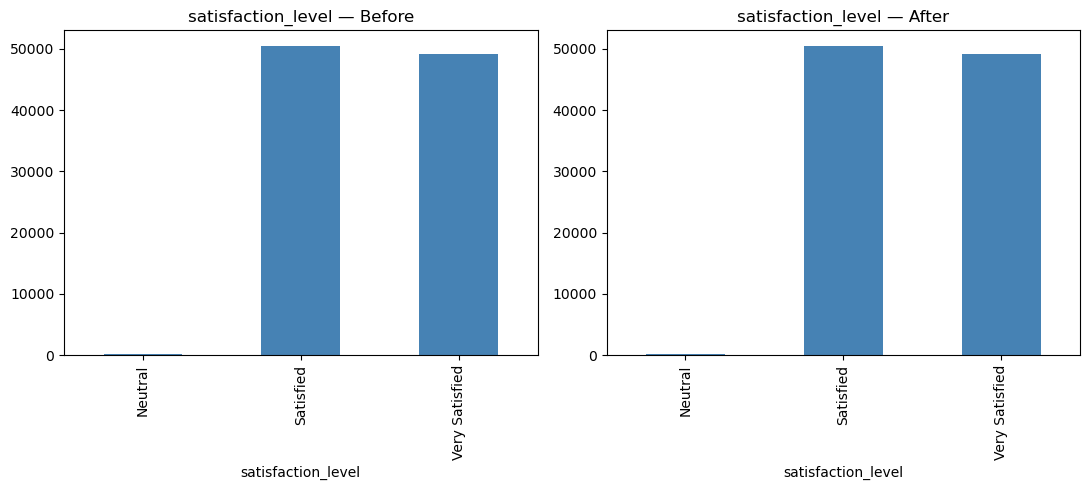

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
df_before["satisfaction_level"].value_counts().reindex(sat_order).plot(
    kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("satisfaction_level — Before")
df_after["satisfaction_level"].value_counts().reindex(sat_order).plot(
    kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("satisfaction_level — After")
plt.tight_layout()
plt.show()

**Interpretation:** The target's class distribution is identical before and after (as it
should be — feature selection only removes *feature* columns, never touches the target or the
rows themselves). This confirms the selection step didn't accidentally distort the outcome
we're trying to predict.